In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline
import os
from pathlib import Path
from tensorflow.keras.utils import to_categorical
from sklearn.utils import shuffle
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
import cv2


In [2]:
# Set data directory path
parent_dir = Path('./brain-mri-images-for-brain-tumor-detection')

# Load image paths and labels
actual_img_paths =[p for child_dir in ["yes", "no"] 
               if (parent_dir / child_dir).is_dir() 
               for p in (parent_dir / child_dir).glob('*') 
               if not p.name.startswith('.')]

labels = [p.parent.name for p in actual_img_paths]

# Create dataframe
df = pd.DataFrame({'filepath': actual_img_paths, 'label': labels})


In [3]:
# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(df['filepath'], df['label'], test_size=0.2, random_state=42)
X_train.size, X_test.size


(202, 51)

In [4]:
from tensorflow.keras.applications.resnet50 import preprocess_input

# Preprocess images for training and testing
def load_and_preprocess_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None 
    img = cv2.resize(img, (224, 224))
    img = preprocess_input(img)
    return img

# Load and preprocess training images
X_train_images = [load_and_preprocess_image(img_path) for img_path in X_train]
X_train_images = np.array([img for img in X_train_images if img is not None])  # Remove failed loads

# Load and preprocess testing images
X_test_images = [load_and_preprocess_image(img_path) for img_path in X_test]
X_test_images = np.array([img for img in X_test_images if img is not None])  # Same


In [5]:
# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test) 

# Shuffle and one-hot encode training labels
X_train_shuffled, y_train_shuffled = shuffle(X_train_images, y_train_encoded, random_state=42)
y_train_shuffled_encoded = to_categorical(y_train_shuffled)
y_test_encoded = to_categorical(y_test_encoded)


In [6]:
# Define data augmentation
demo_datagen = ImageDataGenerator(
    rotation_range=30,             
    width_shift_range=0.15,         
    height_shift_range=0.15,        
    shear_range=0.15,               
    zoom_range=0.15,                
    horizontal_flip=True,           
    vertical_flip=False,            
    fill_mode='nearest',            
    brightness_range=[0.8, 1.2],    
    channel_shift_range=20,
)

# Fit data augmentation generator
demo_datagen.fit(X_train_shuffled)


In [7]:
# Load base ResNet50 model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Build the complete model
input_layer = Input(shape=(224, 224, 3))
x = base_model(input_layer, training=False)
x = Flatten()(x)
x = Dense(224, activation='relu')(x)
x = Dropout(0.5)(x)
output_layer = Dense(2, activation='softmax')(x) 

model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Model summary
model.summary()





Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 flatten (Flatten)           (None, 100352)            0         
                                                                 
 dense (Dense)               (None, 224)               22479072  
                                                                 
 dropout (Dropout)           (None, 224)               0         
                                                                 
 dense_1 (Dense)             (None, 2)                 450       
                                                                 
Total params: 46067234 (175.73 MB)
Trainable params: 22479

In [9]:
# Train the model
history = model.fit(
    demo_datagen.flow(X_train_shuffled, y_train_shuffled_encoded, batch_size=64), 
    epochs=50, 
    validation_data=(X_test_images, y_test_encoded)
)


Epoch 1/50
4/4 [==============================] - 32s 7s/step - loss: 15.8527 - accuracy: 0.5347 - val_loss: 3.6676 - val_accuracy: 0.7647
Epoch 2/50
4/4 [==============================] - 14s 4s/step - loss: 9.7112 - accuracy: 0.7277 - val_loss: 4.7363 - val_accuracy: 0.7451
Epoch 3/50
4/4 [==============================] - 13s 4s/step - loss: 4.5892 - accuracy: 0.7525 - val_loss: 5.6347 - val_accuracy: 0.7255
Epoch 4/50
4/4 [==============================] - 13s 3s/step - loss: 3.8457 - accuracy: 0.7921 - val_loss: 1.5242 - val_accuracy: 0.8627
Epoch 5/50
4/4 [==============================] - 13s 3s/step - loss: 2.2529 - accuracy: 0.8317 - val_loss: 0.9988 - val_accuracy: 0.8824
Epoch 6/50
4/4 [==============================] - 13s 4s/step - loss: 1.6262 - accuracy: 0.8465 - val_loss: 1.1697 - val_accuracy: 0.7647
Epoch 7/50
4/4 [==============================] - 13s 4s/step - loss: 1.6479 - accuracy: 0.7525 - val_loss: 0.6200 - val_accuracy: 0.8431
Epoch 8/50
4/4 [=================

In [10]:
# Save the model
model.save('resnet50_brain_model.h5')


c:\Users\athar\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [11]:
# Make predictions
y_pred = model.predict(X_test_images)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_encoded, axis=1)

# Print classification report and confusion matrix
print("Classification Report:\n", classification_report(y_true, y_pred_classes))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_classes))


2/2 [==============================] - 6s 1s/step
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.79      0.88        24
           1       0.84      1.00      0.92        27

    accuracy                           0.90        51
   macro avg       0.92      0.90      0.90        51
weighted avg       0.92      0.90      0.90        51

Confusion Matrix:
 [[19  5]
 [ 0 27]]


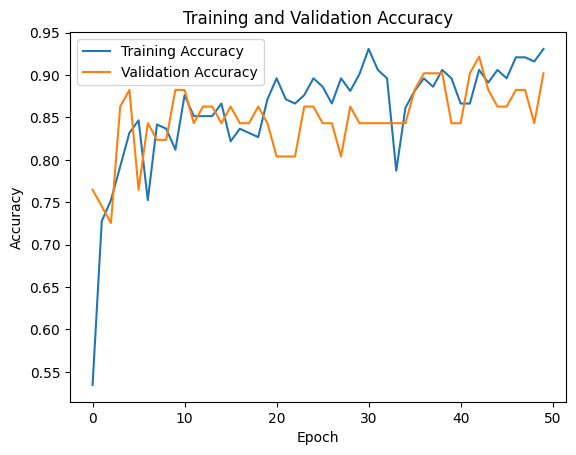

In [12]:
# Plot training and validation accuracy
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.plot(train_accuracy, label='Training Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


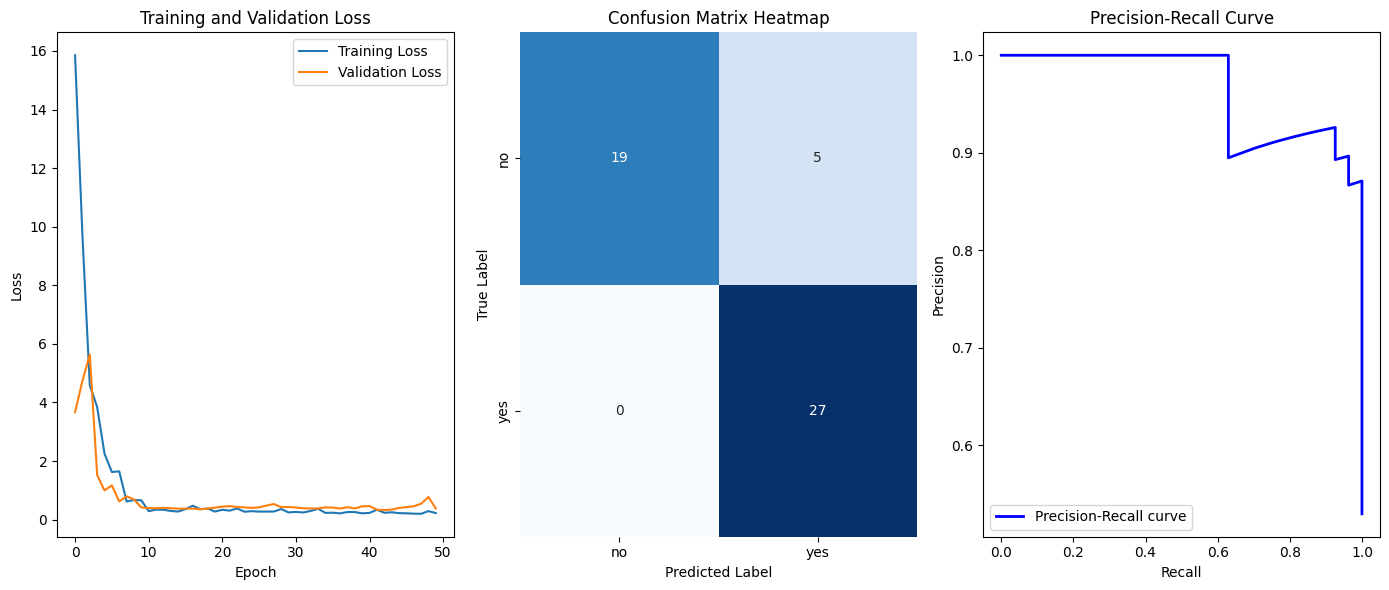

In [13]:
import seaborn as sns
from sklearn.metrics import precision_recall_curve

# Plot training and validation loss
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(14, 6))

# Plot loss
plt.subplot(1, 3, 1)
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

# Compute and plot confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

plt.subplot(1, 3, 2)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')

# Compute and plot precision-recall curve
precision, recall, _ = precision_recall_curve(y_true, y_pred[:, 1])

plt.subplot(1, 3, 3)
plt.plot(recall, precision, color='blue', lw=2, label='Precision-Recall curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()
